# AS5048 encoder noise characterization

Characterizes the sensor noise of the **dial encoder** from a bench capture, and
emits the coefficients for the SIL encoder model's deterministic dither
(`As5048Model::with_noise(sigma_lsb, seed)` — see `docs/sil/backlog.md`,
"Encoder sensor noise").

**Input:** `encoder_noise_raw.csv` (this directory) — `dial_raw` telemetry over
serial at the 2 ms tier; the dial was moved between several rest positions during
the capture, so noise is measured **within stationary dwell segments** only.
The `t` column restarts partway through (concatenated recording sessions); the
analysis is sample-index-based and unaffected.

**Method:** rolling-median dwell segmentation -> per-segment residuals about the
segment median -> pooled sigma / MAD / histogram -> autocorrelation (whiteness)
-> quantization deconvolution -> model coefficients.

Run with the repo venv kernel (`.venv` — matplotlib + ipykernel installed via
`requirements.txt`).

In [1]:
import csv
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

CSV = Path("encoder_noise_raw.csv")
COUNTS_PER_REV = 16384  # AS5048: 14-bit

t_ms, value = [], []
with open(CSV) as f:
    for row in csv.DictReader(f):
        t_ms.append(float(row["t"]))
        value.append(float(row["value"]))
v = np.array(value)
n = len(v)
print(f"{n} samples, value range {v.min():.0f}..{v.max():.0f} counts")

20000 samples, value range 8921..12776 counts


## Raw capture

Rest positions appear as flat dwells; the sweeps between them are dial movement
and are excluded from the noise statistics.

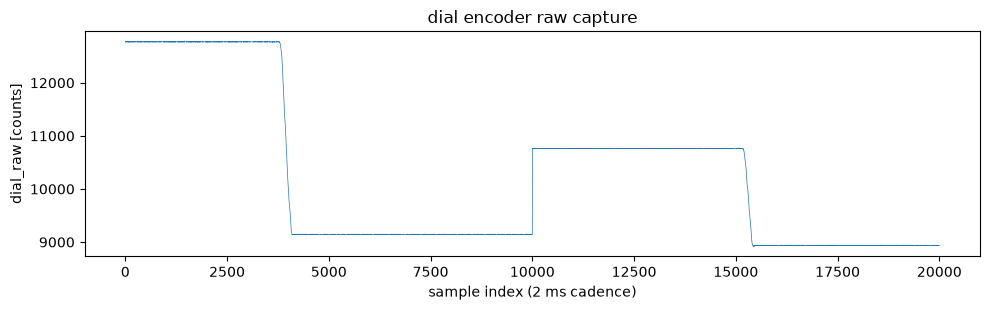

In [2]:
fig, ax = plt.subplots(figsize=(10, 3.2))
ax.plot(v, lw=0.5)
ax.set_xlabel("sample index (2 ms cadence)")
ax.set_ylabel("dial_raw [counts]")
ax.set_title("dial encoder raw capture")
fig.tight_layout()

## Dwell segmentation

A sample is *dwelling* when the local rolling median (window `W`) moves less
than `TOL` counts across the window; contiguous dwell runs of at least
`MIN_LEN` samples become segments. Movement sweeps and short pauses are
discarded.

In [3]:
W, TOL, MIN_LEN = 25, 2.0, 200

med = np.array([np.median(v[max(0, i - W):i + W + 1]) for i in range(n)])
dwelling = np.abs(np.gradient(med)) * W <= TOL

segments, start = [], None
for i, d in enumerate(dwelling):
    if d and start is None:
        start = i
    if (not d or i == n - 1) and start is not None:
        end = i if not d else i + 1
        if end - start >= MIN_LEN:
            segments.append((start, end))
        start = None

pooled = []
print(f"{len(segments)} dwell segments")
print(f"{'range':>16}  {'n':>5}  {'center':>8}  {'sigma':>6}  {'span':>4}")
for s, e in segments:
    seg = v[s:e]
    res = seg - np.median(seg)
    pooled.append(res)
    print(f"[{s:6d}..{e:6d})  {e - s:5d}  {np.median(seg):8.1f}  "
          f"{res.std(ddof=1):6.3f}  {seg.max() - seg.min():4.0f}")
r = np.concatenate(pooled)
print(f"pooled residual samples: {len(r)}")

17 dwell segments
           range      n    center   sigma  span
[   962..  1182)    220   12771.0   1.442     8
[  1653..  1875)    222   12771.0   1.495     7
[  2150..  2429)    279   12771.0   1.323     6
[ 10916.. 11120)    204   10761.0   1.645     9
[ 11140.. 11390)    250   10761.0   1.630     8
[ 11657.. 12249)    592   10761.0   1.589     9
[ 12305.. 12791)    486   10761.0   1.671    10
[ 13638.. 13932)    294   10761.0   1.535     9
[ 13966.. 14330)    364   10761.0   1.538     9
[ 14467.. 14696)    229   10761.0   1.759     9
[ 14728.. 15037)    309   10761.0   1.559    10
[ 15580.. 15883)    303    8937.0   1.560     9
[ 16108.. 16720)    612    8937.0   1.613     9
[ 16723.. 17023)    300    8937.0   1.598     8
[ 17204.. 17595)    391    8937.0   1.621     9
[ 19245.. 19452)    207    8937.0   1.473     8
[ 19637.. 19873)    236    8937.0   1.387     7
pooled residual samples: 5498


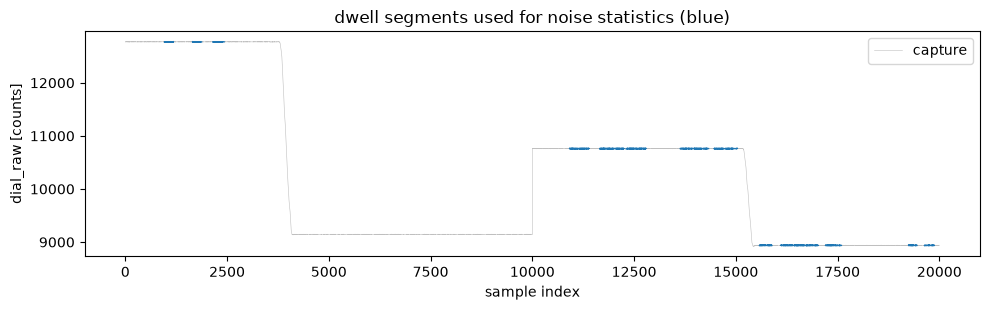

In [4]:
fig, ax = plt.subplots(figsize=(10, 3.2))
ax.plot(v, lw=0.4, color="0.75", label="capture")
for s, e in segments:
    ax.plot(range(s, e), v[s:e], lw=1.0, color="tab:blue")
ax.set_xlabel("sample index")
ax.set_ylabel("dial_raw [counts]")
ax.set_title("dwell segments used for noise statistics (blue)")
ax.legend(loc="upper right")
fig.tight_layout()

## Noise statistics

sigma      = 1.572 LSB  (34.5 mdeg)


MAD-sigma  = 1.483 LSB  (agreement with sigma => Gaussian-consistent)


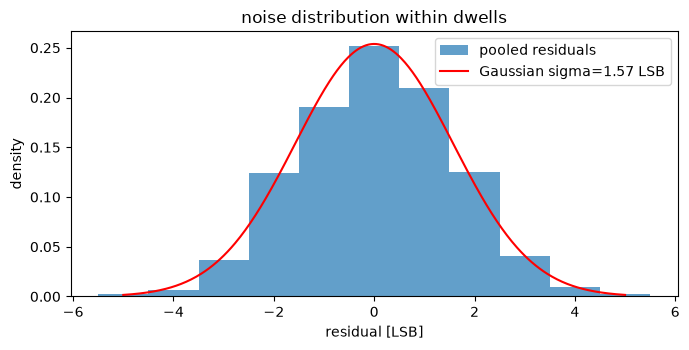

In [5]:
sigma = r.std(ddof=1)
mad_sigma = 1.4826 * np.median(np.abs(r - np.median(r)))
lsb_to_mdeg = 360.0 / COUNTS_PER_REV * 1000.0

bins = np.arange(r.min() - 0.5, r.max() + 1.5)
fig, ax = plt.subplots(figsize=(7, 3.6))
ax.hist(r, bins=bins, density=True, alpha=0.7, label="pooled residuals")
x = np.linspace(r.min(), r.max(), 400)
gauss = np.exp(-0.5 * (x / sigma) ** 2) / (sigma * np.sqrt(2 * np.pi))
ax.plot(x, gauss, "r-", lw=1.5, label=f"Gaussian sigma={sigma:.2f} LSB")
ax.set_xlabel("residual [LSB]")
ax.set_ylabel("density")
ax.set_title("noise distribution within dwells")
ax.legend()
fig.tight_layout()

print(f"sigma      = {sigma:.3f} LSB  ({sigma * lsb_to_mdeg:.1f} mdeg)")
print(f"MAD-sigma  = {mad_sigma:.3f} LSB  (agreement with sigma => Gaussian-consistent)")

## Whiteness

Near-zero autocorrelation at every lag means white noise: an independent draw
per sample is the correct model (no filtering / AR structure needed).

lags 1-5: [0.008, -0.01, 0.002, -0.01, 0.014]


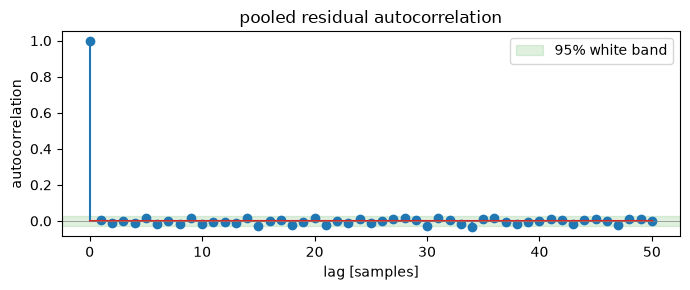

In [6]:
rr = r - r.mean()
ac = np.correlate(rr, rr, "full")[len(rr) - 1:] / (rr.var() * len(rr))
lags = np.arange(0, 51)

fig, ax = plt.subplots(figsize=(7, 3.0))
ax.stem(lags, ac[:51])
ax.axhline(0, color="0.5", lw=0.5)
conf = 1.96 / np.sqrt(len(rr))
ax.axhspan(-conf, conf, color="tab:green", alpha=0.15, label="95% white band")
ax.set_xlabel("lag [samples]")
ax.set_ylabel("autocorrelation")
ax.set_title("pooled residual autocorrelation")
ax.legend()
fig.tight_layout()

print("lags 1-5:", np.round(ac[1:6], 3).tolist())

## Model coefficients

The model adds Gaussian noise in the **angle domain** and then quantizes to
14 bits; quantization itself contributes variance 1/12 LSB^2, so the
angle-domain sigma is deconvolved from the measured (already-quantized)
sigma.

In [7]:
sigma_angle = float(np.sqrt(max(sigma**2 - 1.0 / 12.0, 0.0)))

print("=" * 62)
print("AS5048 dial encoder noise - model coefficients")
print("=" * 62)
print(f"measured pooled sigma : {sigma:.3f} LSB   ({sigma * lsb_to_mdeg:.1f} mdeg)")
print(f"angle-domain sigma    : {sigma_angle:.3f} LSB   (quantization deconvolved)")
print(f"distribution          : Gaussian (MAD agreement), WHITE (autocorr ~ 0)")
print(f"recommended model     : .with_noise(sigma_lsb = {sigma_angle:.2f}, seed)")
print(f"draw site             : per SPI transfer (each poll sees a fresh sample)")
print("=" * 62)

AS5048 dial encoder noise - model coefficients
measured pooled sigma : 1.572 LSB   (34.5 mdeg)
angle-domain sigma    : 1.545 LSB   (quantization deconvolved)
distribution          : Gaussian (MAD agreement), WHITE (autocorr ~ 0)
recommended model     : .with_noise(sigma_lsb = 1.54, seed)
draw site             : per SPI transfer (each poll sees a fresh sample)


## Caveats

- Single sensor, bench temperature, dial channel only — capture the **motor**
  encoder the same way before assuming the same sigma there.
- Telemetry sampled at 2 ms while the firmware reads at 1 ms; white noise is
  insensitive to that decimation.
- No drift was observable within dwells at this record length; if longer
  captures show 1/f drift, the model gains a slow term — measure first.